<a href="https://colab.research.google.com/github/Pramodsingh317/Product-Review-Sentiment-Analyzer/blob/main/Product_Review_Sentiment_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Enter the path to your dataset CSV file: /content/product_reviews_1000.csv

[✓] Successfully loaded 1000 rows from: /content/product_reviews_1000.csv

        EXECUTIVE SENTIMENT REPORT
--- Distribution Breakdown ---
 * Positive  : 62.1%
 * Neutral   : 13.2%
 * Negative  : 24.7%

--- Structural Insights ---
 * Avg. Length (Positive): 8.9 words
 * Avg. Length (Negative): 6.6 words



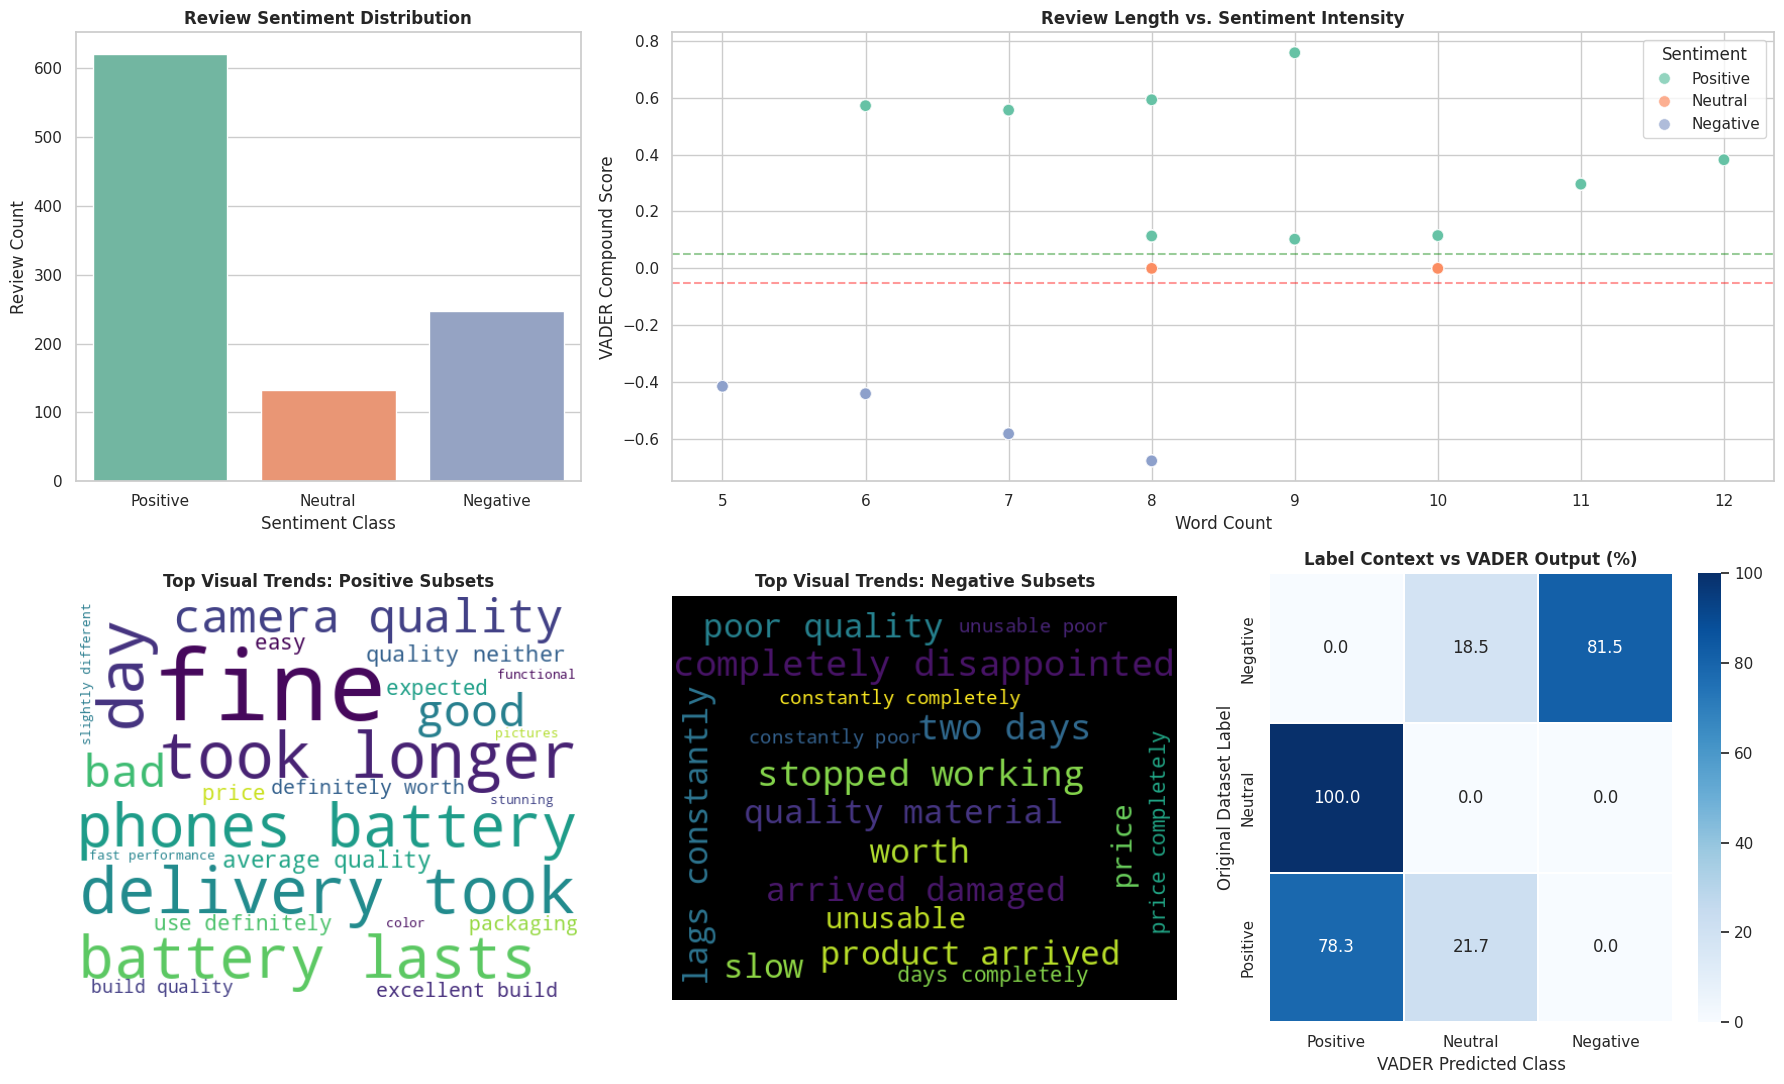

In [ ]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Ensure required NLTK resources are available locally
nltk.download('vader_lexicon', quiet=True)

def load_review_dataset() -> pd.DataFrame:
    """Prompts for and validates a local target reviews CSV file path."""
    csv_path = input("\nEnter the path to your dataset CSV file: ").strip().strip("'\"")

    # Enforce local disk constraints
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Local dataset file not found at: {csv_path}")

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Operational schema validations
    required_columns = ['Review Text', 'Label']
    if not all(col in df.columns for col in required_columns):
        raise KeyError(
            f"Missing required columns. Expected {required_columns}, but found {list(df.columns)}"
        )

    print(f"\n[✓] Successfully loaded {len(df)} rows from: {csv_path}")
    return df

def clean_review_text(text: any) -> str:
    """Sanitizes text by stripping HTML, special characters, and numbers."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def get_sentiment_label(score: float) -> str:
    """Maps a VADER compound score to a standard human-readable sentiment label."""
    if score >= 0.05:
        return 'Positive'
    if score <= -0.05:
        return 'Negative'
    return 'Neutral'

def analyze_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    """Computes sentiment metrics and text structural features."""
    df['Cleaned_Review'] = df['Review Text'].apply(clean_review_text)
    df['Word_Count'] = df['Cleaned_Review'].apply(lambda text: len(text.split()))

    analyzer = SentimentIntensityAnalyzer()
    df['VADER_Score'] = df['Cleaned_Review'].apply(lambda text: analyzer.polarity_scores(text)['compound'])
    df['Sentiment_Class'] = df['VADER_Score'].apply(get_sentiment_label)

    return df

def generate_insights_dashboard(df: pd.DataFrame):
    """Renders distribution plots, structural correlations, text insights, and a heatmap matrix."""
    sns.set_theme(style="whitegrid")
    sentiment_order = ['Positive', 'Neutral', 'Negative']
    palette_mapping = {'Positive': '#66c2a5', 'Neutral': '#fc8d62', 'Negative': '#8da0cb'}

    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(2, 3)

    # 1. Distribution of Sentiments
    ax1 = fig.add_subplot(gs[0, 0])
    sns.countplot(
        x='Sentiment_Class',
        data=df,
        hue='Sentiment_Class',
        palette=palette_mapping,
        order=sentiment_order,
        legend=False,
        ax=ax1
    )
    ax1.set_title('Review Sentiment Distribution', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Sentiment Class')
    ax1.set_ylabel('Review Count')

    # 2. Text Length vs. VADER Score Correlation
    ax2 = fig.add_subplot(gs[0, 1:])
    sns.scatterplot(x='Word_Count', y='VADER_Score', hue='Sentiment_Class', data=df,
                    palette=palette_mapping, hue_order=sentiment_order, s=70, alpha=0.7, ax=ax2)
    ax2.axhline(0.05, color='green', linestyle='--', alpha=0.4)
    ax2.axhline(-0.05, color='red', linestyle='--', alpha=0.4)
    ax2.set_title('Review Length vs. Sentiment Intensity', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Word Count')
    ax2.set_ylabel('VADER Compound Score')
    ax2.legend(title='Sentiment')

    # 3. Dynamic WordCloud Generators
    for idx, (sentiment, bg_color) in enumerate([('Positive', 'white'), ('Negative', 'black')]):
        ax_wc = fig.add_subplot(gs[1, idx])
        subset_text = " ".join(df[df['Sentiment_Class'] == sentiment]['Cleaned_Review']).strip()

        if subset_text:
            wordcloud = WordCloud(width=500, height=400, background_color=bg_color, max_words=25).generate(subset_text)
            ax_wc.imshow(wordcloud, interpolation='bilinear')
            ax_wc.set_title(f'Top Visual Trends: {sentiment} Subsets', fontsize=12, fontweight='bold')
        else:
            ax_wc.text(0.5, 0.5, f'No {sentiment} Reviews Found', ha='center', va='center', fontsize=12)

        ax_wc.axis('off')

    # 4. Context Heatmap
    ax_heatmap = fig.add_subplot(gs[1, 2])
    crosstab_matrix = pd.crosstab(df['Label'], df['Sentiment_Class'], normalize='index') * 100

    for label in sentiment_order:
        if label not in crosstab_matrix.columns:
            crosstab_matrix[label] = 0.0
    crosstab_matrix = crosstab_matrix[sentiment_order]

    sns.heatmap(crosstab_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True,
                linewidths=1.2, linecolor='white', square=False, ax=ax_heatmap)

    ax_heatmap.set_title('Label Context vs VADER Output (%)', fontsize=12, fontweight='bold')
    ax_heatmap.set_xlabel('VADER Predicted Class')
    ax_heatmap.set_ylabel('Original Dataset Label')

    plt.tight_layout()
    plt.show()

def print_summary_report(df: pd.DataFrame):
    """Outputs a clean executive performance overview to the console."""
    print("\n" + "="*45)
    print("        EXECUTIVE SENTIMENT REPORT")
    print("="*45)

    breakdown = df['Sentiment_Class'].value_counts(normalize=True) * 100
    print("--- Distribution Breakdown ---")
    for sentiment in ['Positive', 'Neutral', 'Negative']:
        pct = breakdown.get(sentiment, 0.0)
        print(f" * {sentiment.ljust(9)} : {pct:.1f}%")

    print("\n--- Structural Insights ---")
    for sentiment in ['Positive', 'Negative']:
        avg_len = df[df['Sentiment_Class'] == sentiment]['Word_Count'].mean()
        if not np.isnan(avg_len):
            print(f" * Avg. Length ({sentiment}): {avg_len:.1f} words")
        else:
            print(f" * Avg. Length ({sentiment}): N/A (No records found)")
    print("="*45 + "\n")

if __name__ == "__main__":
    try:
        reviews_df = load_review_dataset()
        reviews_df = analyze_sentiment(reviews_df)
        print_summary_report(reviews_df)
        generate_insights_dashboard(reviews_df)
    except Exception as error:
        print(f"\n[×] Process terminated prematurely: {error}")
